In [2]:
# Grundläggande bibliotek
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Train/validation-split
from sklearn.model_selection import train_test_split

#import sys
#!{sys.executable} -m pip install tensorflow

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.keras.utils.set_random_seed(42)


In [3]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

print("X_train_full shape:", X_train_full.shape)
print("y_train_full shape:", y_train_full.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train_full shape: (60000, 28, 28)
y_train_full shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [4]:
print("Unika labels:", np.unique(y_train_full))

print("Minsta pixelvärde:", X_train_full.min())
print("Största pixelvärde:", X_train_full.max())

Unika labels: [0 1 2 3 4 5 6 7 8 9]
Minsta pixelvärde: 0
Största pixelvärde: 255


In [5]:
# Class names
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

class_counts = pd.Series(y_train_full).value_counts().sort_index()

class_distribution = pd.DataFrame({
    "class_id": class_counts.index,
    "class_name": [class_names[i] for i in class_counts.index],
    "count": class_counts.values
})

class_distribution

,class_id,class_name,count
0,0,T-shirt/top,6000
1,1,Trouser,6000
2,2,Pullover,6000
3,3,Dress,6000
4,4,Coat,6000
5,5,Sandal,6000
6,6,Shirt,6000
7,7,Sneaker,6000
8,8,Bag,6000
9,9,Ankle boot,6000


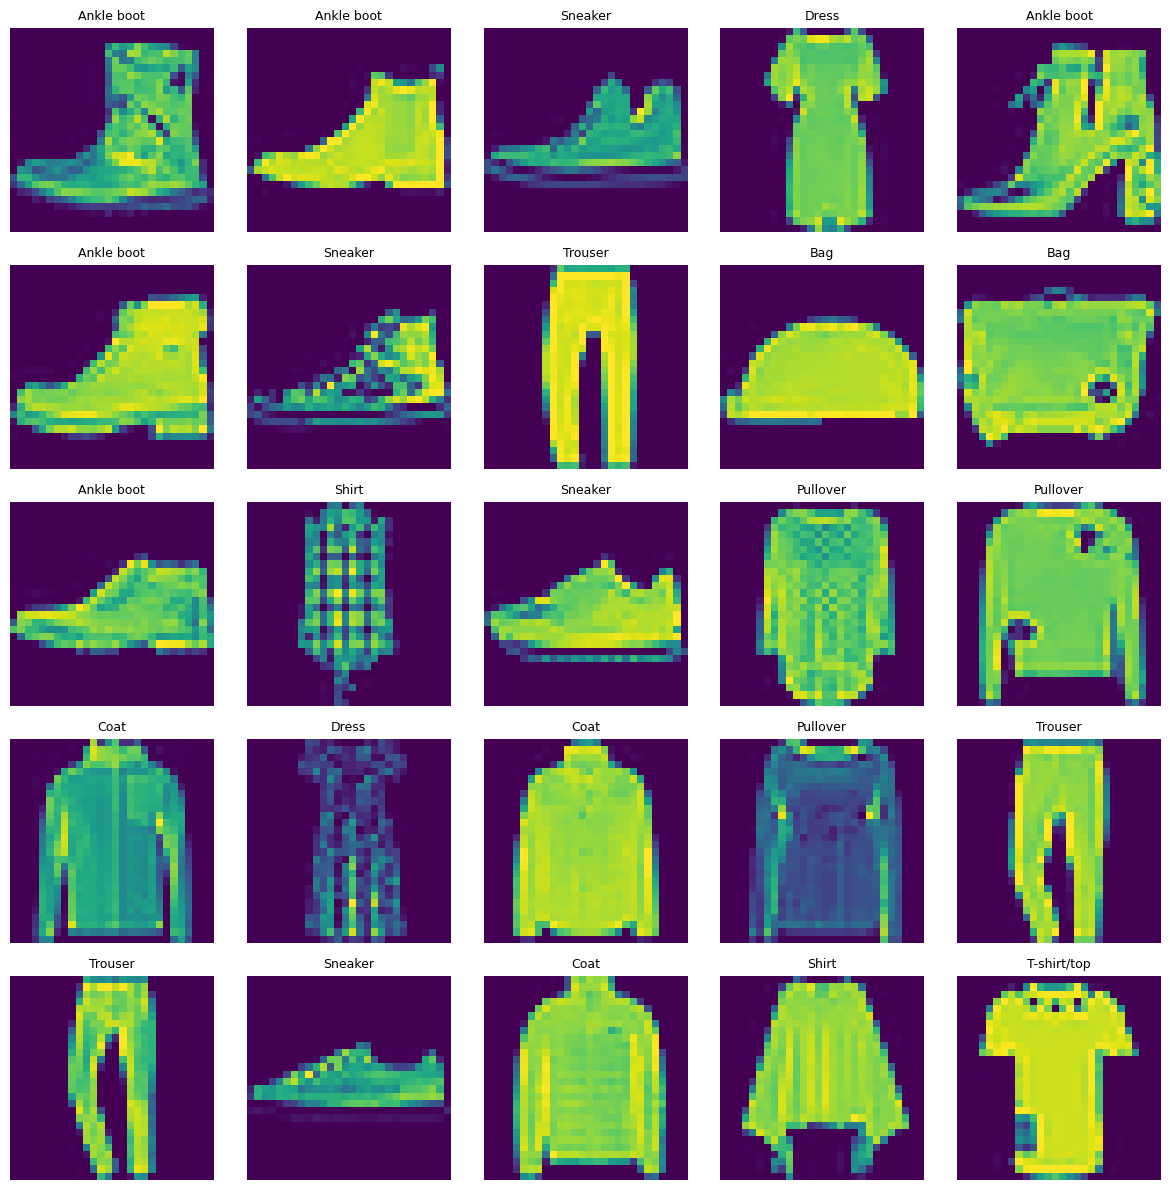

In [6]:
def  plot_image_grid(X, y, class_names, n_images=25, random_state=42):
    rng = np.random.default_rng(random_state)
    indices = rng.choice(len(X), size=n_images, replace=False)

    grid_size = int(np.ceil(np.sqrt(n_images)))

    plt.figure(figsize=(12, 12))
    
    for plot_index, image_index in enumerate(indices):
        plt.subplot(grid_size, grid_size, plot_index + 1)
        plt.imshow(X[image_index])
        plt.title(class_names[y[image_index]], fontsize=9)
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()


plot_image_grid(
    X_train_full,
    y_train_full,
    class_names,
    n_images=25
)

## Dataförståelse

Datasetet innehåller totalt **70 000 bilder**, där `X_train_full` består av **60 000 träningsbilder** och `X_test` av **10 000 testbilder**. Varje bild har storleken **28 × 28 pixlar**, och tillhörande etiketter finns i `y_train_full` och `y_test`.

Datasetet innehåller 10 klasser:

- T-shirt/top
- Trouser
- Pullover
- Dress
- Coat
- Sandal
- Shirt
- Sneaker
- Bag
- Ankle boot

Varje klass innehåller **6000 bilder**, vilket innebär att datasetet är **balanserat** utan över- eller underrepresenterade klasser.

Baserat på de första 25 bilderna som visualiserades verkar även etiketteringen vara korrekt, då bilderna överensstämde med sina respektive klasser.

In [7]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.10,
    random_state=42,
    stratify=y_train_full
)

print("X_train", X_train.shape)
print("X_val", X_val.shape)
print("X_test", X_test.shape)

X_train (54000, 28, 28)
X_val (6000, 28, 28)
X_test (10000, 28, 28)


In [8]:
X_train = X_train.astype("float32") / 255.0
X_val = X_val.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0


print("Minsta värde efter normalisering:", X_train.min())
print("Största värde efter normalisering:", X_train.max())

X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print("X_train shape efter kanal-dimension:", X_train.shape)
print("X_val shape efter kanal-dimension:", X_val.shape)
print("X_test shape efter kanal-dimension:", X_test.shape)

Minsta värde efter normalisering: 0.0
Största värde efter normalisering: 1.0
X_train shape efter kanal-dimension: (54000, 28, 28, 1)
X_val shape efter kanal-dimension: (6000, 28, 28, 1)
X_test shape efter kanal-dimension: (10000, 28, 28, 1)


## Förberedelse av data


### Dela upp träningsdata i träning och validering
Vi delar upp `X_train_full` och `y_train_full` i:

- **Träningsdata (X_train, y_train)**
- **Valideringsdata (X_val, y_val)**

Vi använder:
- 10% av datan som valideringsset (`test_size=0.10`)
- `stratify=y_train_full` för att behålla samma klassfördelning i båda delarna
- `random_state=42` för att få samma uppdelning varje gång

### Normalisering av pixelvärden
Vi konverterar bilderna till `float32` och skalar pixelvärden från:

- **0–255 → 0–1**

Detta görs för:
- snabbare och stabilare träning
- bättre numerisk stabilitet i modellen

Vi verifierar även att:
- minsta värde ≈ 0
- största värde ≈ 1

### Lägga till kanal-dimension
Eftersom bilderna är gråskaliga lägger vi till en extra dimension:

- Från: `(28, 28)`
- Till: `(28, 28, 1)`

Detta krävs för att neurala nätverk (t.ex. CNN) ska kunna behandla bilderna korrekt.

In [9]:
model = keras.Sequential()

model.add(layers.Input(shape=(28, 28, 1)))
model.add(layers.Conv2D(32, (3, 3), padding="same", activation="relu"))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), padding="same", activation="relu"))
model.add(layers.MaxPooling2D(2, 2))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation="relu"))
model.add(layers.Dense(10, activation="softmax"))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,234 (860.29 KB)

 Trainable params: 220,234 (860.29 KB)

 Non-trainable params: 0 (0.00 B)

### Modellskapande 
Vi bygger en sekventiell modell med följande lager:

- Conv2D (32 filter, 3×3) — extraherar lokala mönster (kanter, texturer)
- MaxPooling2D (2×2) — minskar dimensionerna och behåller viktigaste informationen
- Conv2D (64 filter, 3×3) — extraherar mer komplexa mönster
- MaxPooling2D (2×2) — ytterligare dimensionsreduktion
- Flatten — gör om 2D-features till en 1D-vektor
- Dense (64 neuroner, ReLU) — lär sig kombinationer av features
- Dense (10 neuroner, softmax) — ger sannolikheter för varje klass (0–9)

Vi använder padding="same" för att behålla bildens dimensioner genom konvolutionslagren.

In [10]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

### Kompilering
Modellen kompileras med:

- Optimizer: Adam(learning_rate=0.001) -- adaptiv inlärning
- Loss: SparseCategoricalCrossentropy -- lämplig för flerklass-klassificering
- Metric: Accuracy -- andel korrekta klassificeringar

In [11]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=64
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8342 - loss: 0.4607 - val_accuracy: 0.8695 - val_loss: 0.3615
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8931 - loss: 0.3009 - val_accuracy: 0.8873 - val_loss: 0.3122
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9081 - loss: 0.2560 - val_accuracy: 0.8938 - val_loss: 0.2974
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9190 - loss: 0.2253 - val_accuracy: 0.9023 - val_loss: 0.2756
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9278 - loss: 0.1999 - val_accuracy: 0.9043 - val_loss: 0.2734


### Träning
Modellen tränas med:

- 5 epoker -- varje epok går igenom hela träningsdatan en gång
- Batch size 64 -- uppdaterar vikterna efter varje batch
- Valideringsdata -- utvärderar modellen på osedd data efter varje epok

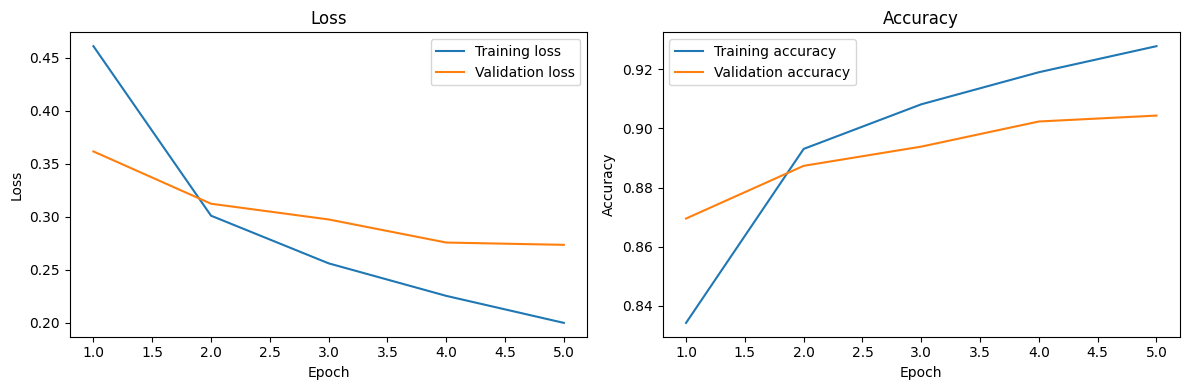

In [12]:
def plot_history(history):
    history_df = pd.DataFrame(history.history)

    epochs = range(1, len(history_df) +1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history_df["loss"], label="Training loss")
    plt.plot(epochs, history_df["val_loss"], label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history_df["accuracy"], label="Training accuracy")
    plt.plot(epochs, history_df["val_accuracy"], label="Validation accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

### Visualisering av träningshistorik
Vi plottar:

- Loss (träning vs validering) -- visar om modellen överanpassar
- Accuracy (träning vs validering) -- visar hur väl modellen generaliserar

### Test och förbättring av modellen

- Vi testar olika förändringar i modellen för att se om resultatet förbättras.

- Vi testar fler neuroner, fler filter och ändrad learning rate.


In [13]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_baseline = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val, y_val)
)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9362 - loss: 0.1783 - val_accuracy: 0.9078 - val_loss: 0.2644
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9447 - loss: 0.1560 - val_accuracy: 0.9037 - val_loss: 0.2930
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9510 - loss: 0.1385 - val_accuracy: 0.8980 - val_loss: 0.3176
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9568 - loss: 0.1225 - val_accuracy: 0.8998 - val_loss: 0.3376
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9634 - loss: 0.1067 - val_accuracy: 0.9030 - val_loss: 0.3423
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9661 - loss: 0.0955 - val_accuracy: 0.9135 - val_loss: 0.2984
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9689 - loss: 0.0877 - val_accuracy: 0.9065 - val_loss: 0.3358
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9737 - loss: 0.0757 - val_accuracy: 0.

### Baseline-modell

Först tränas originalmodellen för att få ett resultat att jämföra med.

In [14]:
baseline_test_loss, baseline_test_accuracy = model.evaluate(X_test, y_test)

print("Baseline test loss:", baseline_test_loss)
print("Baseline test accuracy:", baseline_test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9008 - loss: 0.4451
Baseline test loss: 0.44505757093429565
Baseline test accuracy: 0.9007999897003174


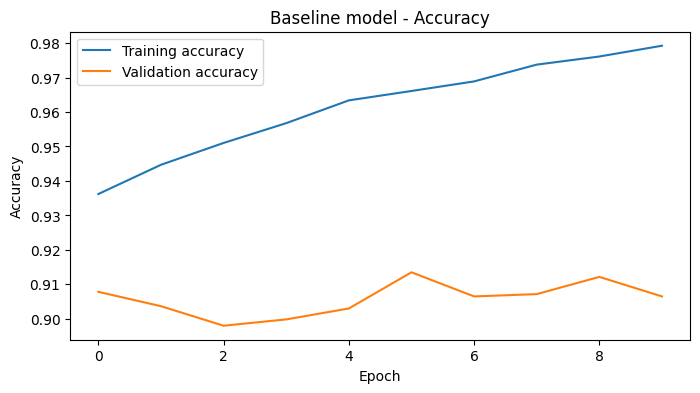

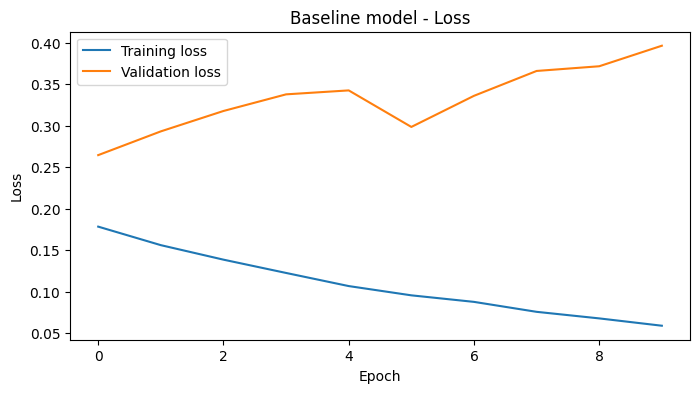

In [15]:
def plot_history(history, title):
    plt.figure(figsize=(8, 4))
    plt.plot(history.history["accuracy"], label="Training accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation accuracy")
    plt.title(title + " - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(history.history["loss"], label="Training loss")
    plt.plot(history.history["val_loss"], label="Validation loss")
    plt.title(title + " - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

plot_history(history_baseline, "Baseline model")

### Testar med fler neuroner

ökar antalet neuroner i Dense-lagret från 64 till 128.

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8389 - loss: 0.4469 - val_accuracy: 0.8788 - val_loss: 0.3332
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8945 - loss: 0.2935 - val_accuracy: 0.8973 - val_loss: 0.2883
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9111 - loss: 0.2457 - val_accuracy: 0.9062 - val_loss: 0.2609
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9220 - loss: 0.2125 - val_accuracy: 0.9103 - val_loss: 0.2494
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9328 - loss: 0.1851 - val_accuracy: 0.9115 - val_loss: 0.2492
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9433 - loss: 0.1602 - val_accuracy: 0.9067 - val_loss: 0.2721
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9504 - loss: 0.1380 - val_accuracy: 0.9137 - val_loss: 0.2617
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9580 - loss: 0.1176 - val_accuracy: 0.

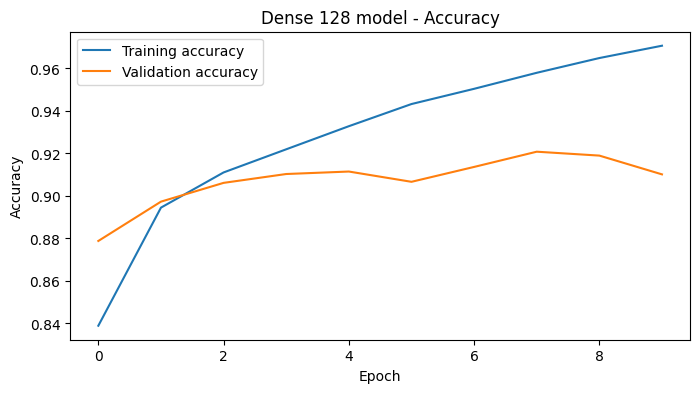

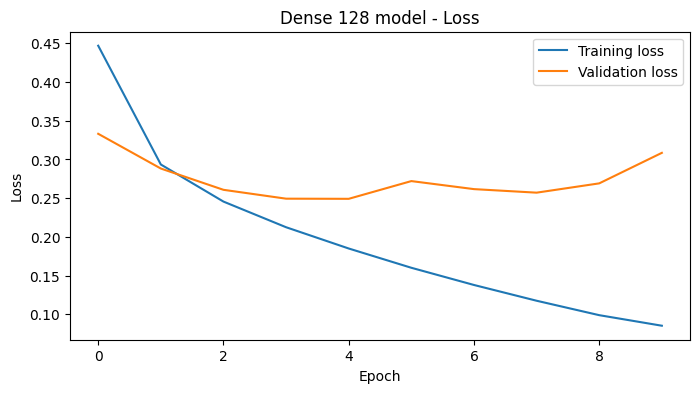

In [16]:
model_dense_128 = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model_dense_128.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_dense_128 = model_dense_128.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val, y_val)
)

dense_128_test_loss, dense_128_test_accuracy = model_dense_128.evaluate(X_test, y_test)

print("Dense 128 test loss:", dense_128_test_loss)
print("Dense 128 test accuracy:", dense_128_test_accuracy)

plot_history(history_dense_128, "Dense 128 model")

### Testar med fler filter

testar med fler filter i Conv2D-lagren.

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - accuracy: 0.8426 - loss: 0.4379 - val_accuracy: 0.8895 - val_loss: 0.3045
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.8976 - loss: 0.2849 - val_accuracy: 0.9010 - val_loss: 0.2669
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.9128 - loss: 0.2383 - val_accuracy: 0.9065 - val_loss: 0.2562
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.9259 - loss: 0.2037 - val_accuracy: 0.9085 - val_loss: 0.2557
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.9361 - loss: 0.1748 - val_accuracy: 0.9093 - val_loss: 0.2621
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.9457 - loss: 0.1502 - val_accuracy: 0.9150 - val_loss: 0.2514
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.9556 - loss: 0.1268 - val_accuracy: 0.9128 - val_loss: 0.2685
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.9627 - loss: 0.1085 - 

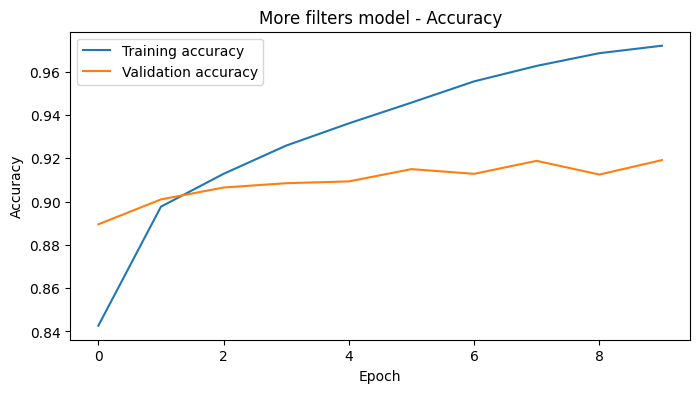

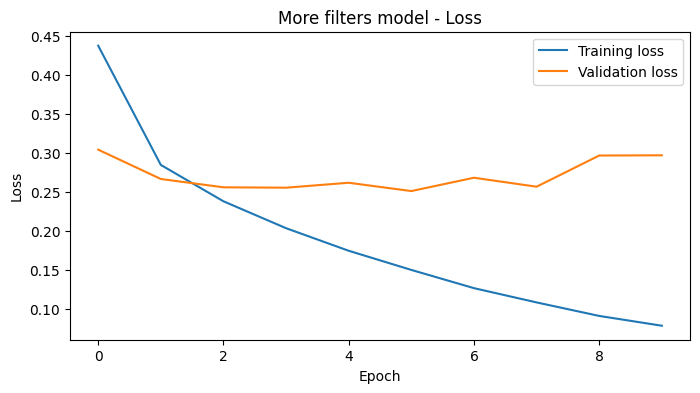

In [17]:
model_more_filters = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model_more_filters.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_more_filters = model_more_filters.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val, y_val)
)

more_filters_test_loss, more_filters_test_accuracy = model_more_filters.evaluate(X_test, y_test)

print("More filters test loss:", more_filters_test_loss)
print("More filters test accuracy:", more_filters_test_accuracy)

plot_history(history_more_filters, "More filters model")

### Testar med lägre learning rate

testar med en lägre learning rate.

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8156 - loss: 0.5187 - val_accuracy: 0.8515 - val_loss: 0.3975
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8779 - loss: 0.3405 - val_accuracy: 0.8772 - val_loss: 0.3345
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8929 - loss: 0.2968 - val_accuracy: 0.8885 - val_loss: 0.3005
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9024 - loss: 0.2690 - val_accuracy: 0.8997 - val_loss: 0.2739
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9102 - loss: 0.2475 - val_accuracy: 0.9063 - val_loss: 0.2564
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9170 - loss: 0.2288 - val_accuracy: 0.9127 - val_loss: 0.2421
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9231 - loss: 0.2117 - val_accuracy: 0.9163 - val_loss: 0.2337
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9301 - loss: 0.1960 - val_accuracy: 0.

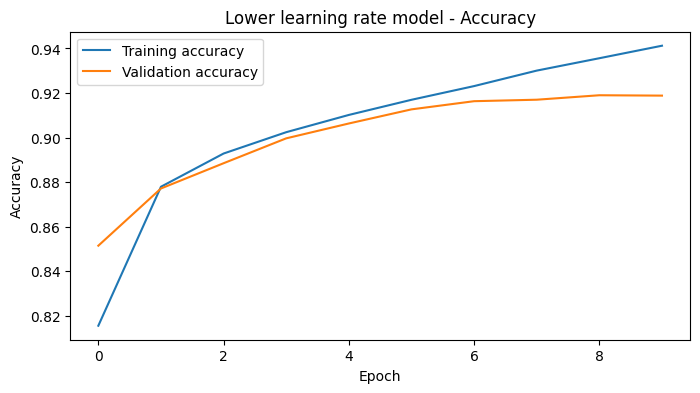

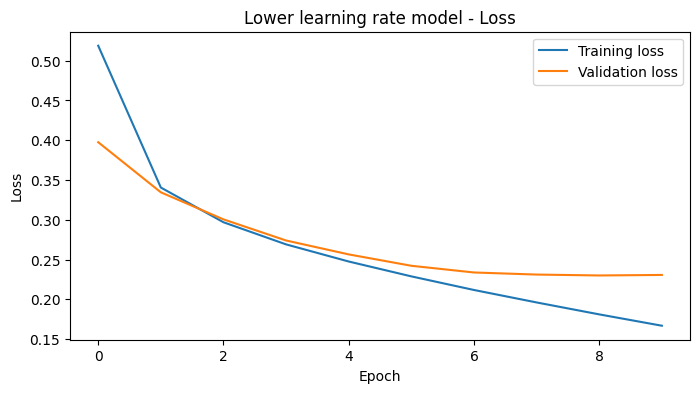

In [18]:
model_lower_lr = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

optimizer = keras.optimizers.Adam(learning_rate=0.0005)

model_lower_lr.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_lower_lr = model_lower_lr.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val, y_val)
)

lower_lr_test_loss, lower_lr_test_accuracy = model_lower_lr.evaluate(X_test, y_test)

print("Lower learning rate test loss:", lower_lr_test_loss)
print("Lower learning rate test accuracy:", lower_lr_test_accuracy)

plot_history(history_lower_lr, "Lower learning rate model")

### Jämförelse av modellerna

jämför modellerna med test accuracy och test loss.

In [19]:
results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Dense 128",
        "More filters",
        "Lower learning rate"
    ],
    "Test loss": [
        baseline_test_loss,
        dense_128_test_loss,
        more_filters_test_loss,
        lower_lr_test_loss
    ],
    "Test accuracy": [
        baseline_test_accuracy,
        dense_128_test_accuracy,
        more_filters_test_accuracy,
        lower_lr_test_accuracy
    ]
})

results

,Model,Test loss,Test accuracy
0,Baseline,0.445058,0.9008
1,Dense 128,0.363575,0.8981
2,More filters,0.353888,0.9066
3,Lower learning rate,0.262463,0.9111


### Analys

Förändringar i modellen påverkade resultatet på olika sätt.

Modellen med lägre learning rate presterade bäst och fick högst test accuracy samt lägst test loss.

Det tyder på att en lägre learning rate gjorde träningen stabilare och hjälpte modellen att lära sig bättre.